In [ ]:
#Irem_Dogruoglu_7061348_Lizzie_Schmitz_7056551
#References:
#1.https://matplotlib.org/stable/tutorials/introductory/pyplot.html
#2.https://github.com/gnina/gnina
#3.https://github.com/RMeli/gnina-torch

In [89]:
import os
os.chdir(r'C:\Users\aesch\Documents\UdS\SoSe2026\DL\Project\DLDockingBenchSeminar')

In [94]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

#Getting the right directories for inputs and outputs. 
RESULTS_PT = Path("results")
POSEBUSTERS_PT = RESULTS_PT/ "results_posebusters_redocking"
TEST_PT = RESULTS_PT / "full_test_redocked"
MODEL_DIR = RESULTS_PT / "gninatorch_training"
REDO_MODEL_DIR = RESULTS_PT / "posebusters_filtered"
PLOTS_DIR = RESULTS_PT / "plots"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# loop to iterate over all trained model directories
trained_model_dirs = [d for d in MODEL_DIR.iterdir() if d.is_dir()]

MODEL_DIR, REDO_MODEL_DIR, PLOTS_DIR, trained_model_dirs

(WindowsPath('results/gninatorch_training'),
 WindowsPath('results/posebusters_filtered'),
 WindowsPath('results/plots'),
 [WindowsPath('results/gninatorch_training/default2018_seed1'),
  WindowsPath('results/gninatorch_training/dense_seed1')])

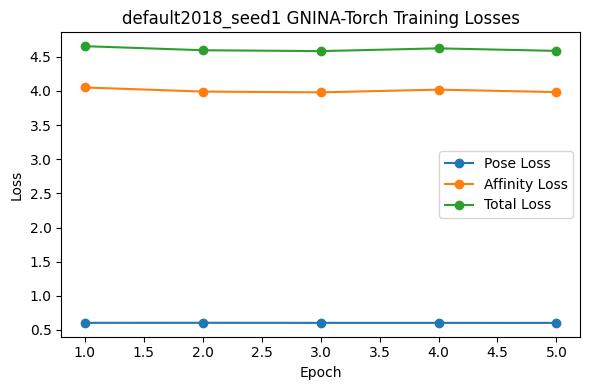

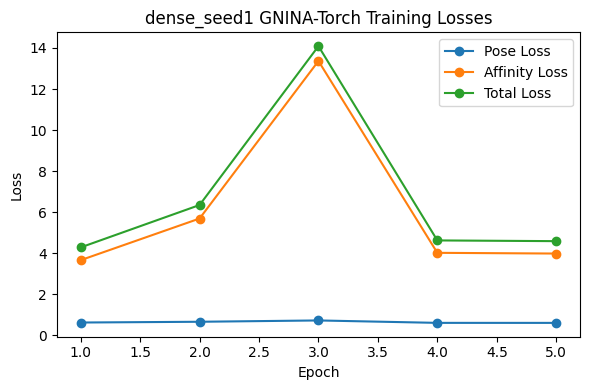

In [86]:
#GNINA-Torch training and test pose loss plot shows how the pose loss evolves over epochs for the training and the test metrics, which enables whether the retrained model is learning and are there overfittings.
def log_metrics_train(log_fl: Path):
    metrics = {}
    if not log_fl.exists(): # error handling 
        print(f"skipping: training log not found: {log_fl}")
        return metrics

    key_map = { # dict structure
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Pose Loss": "pose_loss",
        "ROC AUC": "roc_auc",
        "MAE": "mae",
        "RMSE": "rmse",
        "Affinity Loss": "affinity_loss",
        "Loss": "loss",
        "Epoch Time": "epoch_time",
        "Elapsed Time": "elapsed_time",
    }

    updated_epch = None

    with log_fl.open(errors="ignore") as f:
        for line in f:
            line = line.strip()

            # use regex expressions for flexibility while parsing metrics
            # find the training results per epoch (find headers)
            train_mtc = re.search(  
                r">>>\s*Train Results\s*-\s*Epoch\[(\d+)\]",
                line,
                re.IGNORECASE,
            )
            if train_mtc: # if there is a header line, create a new dict entry for the metrics of each training epoch
                updated_epch = int(train_mtc.group(1))
                metrics[updated_epch] = {}
                continue

            if updated_epch is None:
                continue

            metric_mtch = re.match( # for each line, find out if a metric in the dict is mentioned
                r"(.+?):\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
                line,
            )
            if metric_mtch: # get the titles (raw_key) of each line and its contents (value)
                raw_key = metric_mtch.group(1).strip()
                value = float(metric_mtch.group(2))
                if raw_key in key_map: # if the raw_key is a valid metric in the dict, put the metric and its value into the metrics dict
                    metrics[updated_epch][key_map[raw_key]] = value

    return metrics

#Iretaring over each trained model directory.
for model_dir in trained_model_dirs: 
    model_name = model_dir.name # either dense or default2018 model

    log_fl = model_dir / "training.log"
    metrics_log = log_metrics_train(log_fl)

    epochs = sorted(metrics_log.keys()) # sort by epoch dict
    pose_loss = [metrics_log[e]["pose_loss"] for e in epochs if "pose_loss" in metrics_log[e]]
    affinity_loss = [metrics_log[e]["affinity_loss"] for e in epochs if "affinity_loss" in metrics_log[e]]
    total_loss = [metrics_log[e]["loss"] for e in epochs if "loss" in metrics_log[e]]

    plt.figure(figsize=(6,4))
    if pose_loss:
        plt.plot(epochs, pose_loss, marker="o", label="Pose Loss")
    if affinity_loss:
        plt.plot(epochs, affinity_loss, marker="o", label="Affinity Loss")
    if total_loss:
        plt.plot(epochs, total_loss, marker="o", label="Total Loss")

    plt.title(f"{model_name} GNINA-Torch Training Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
#Figures explanation:
#The GNINA-Torch training curves for the dense_seed1 model illustrate the progress of pose loss, affinity loss, and total loss over the course of our five epochs. 
# For the dense model, though affinity and total loss rise rapidly around epoch 4 before declining once more at epoch 5, pose loss remains very low and fluctuates just slightly. This pattern implies that the model may still be under-trained or sensitive to learning-rate and optimisation settings because the brief training session did not reach a stable minimum.
# The default2018_seed1 model exhibits a flat training curve: this indicates that training ultimately failed over the 5 epochs. There appears to be only slight fluctuations in the curve over the course of 5 epochs.
# These poor training loss curves could explain the failure of the model to accurately predict CNNpose_score/CNNaffinity. This model collapse could be explained by an unsuitably high learning rate for the small amount of epochs,  

In [ ]:
"""
First, for the Posebusters dataset, onto the preexisting evaluation.py-generated CSV files, add on CNNaffinity and CNNpose score as new columns in the CSV. Use CNN_metrics_to_csv.py to first parse the CNNaffinity and CNNpose_score values from the .sdf files to add to the csvs.  
"""

def parse_gnina_sdf_scores(sdf_file: Path):
    """
    This function reads the full SDF text and searches for multiple possible name variants, so that GNINA naming conventions can still be visible.
    Uses argument of sdf_file as SDF output file, and returns a tuple containing all parsed CNN pose score and CNN affinity score values.
    """
    text = sdf_file.read_text(errors="ignore")

    pose_scores = []
    affinity_scores = []

    #Including multiple labels used in GNINA SDF files for flexibility
    score_patterns = ["CNNscore", "CNN_score", "CNN_pose_score", "CNN Pose Score", "CNN pose score"]
    affinity_patterns = ["CNNaffinity", "CNN_affinity", "CNN Affinity", "CNN affinity"]

    #Extracting floating-point values in SDF property tags
    # Use regex expressions for more flexibility
    for pattern in score_patterns:
        matches = re.findall(rf">\s*<\s*{re.escape(pattern)}\s*>\s*\n([-\d.eE]+)", text)
        pose_scores.extend(float(x) for x in matches)

    for pattern in affinity_patterns:
        matches = re.findall(rf">\s*<\s*{re.escape(pattern)}\s*>\s*\n([-\d.eE]+)", text)
        affinity_scores.extend(float(x) for x in matches)

    return pose_scores, affinity_scores


def collect_metrics(model_name: str, model_dir: Path):
    
    """
    This function gathers all CNN pose scores, and CNN affinity scores from the .sdf files in the dir. Then results are stored as a list of dictionaries.
    """
        
    rows = []

    for pred_sdf in sorted(model_dir.glob("*.sdf")):

        pose_scores, affinity_scores = parse_gnina_sdf_scores(pred_sdf)

        rows.append(
            {
                "model": model_name,
                "complex_id": pred_sdf.stem.replace("_pred", ""), # remove _pred suffix
                "CNNpose_score": pose_scores[0] if pose_scores else None, # for top 1 
                "CNNaffinity": affinity_scores[0] if affinity_scores else None,
                "num_poses": max(len(pose_scores), len(affinity_scores)),
            }
        )

    return rows

"""
Now, add these CNNaffinity and CNNpose_score columns to the pre-existing
evaluation.py-generated CSV files.
"""

# Map each model to its evaluation CSV filename with a dict
evaluation_csv_names = {
    "default2018_seed1": "posebusters_filtered_evaluation_default2018_seed1_full",
    "dense_seed1": "posebusters_filtered_evaluation_dense_seed1_full",
}


def sdf_to_complex_id(file) -> str:
    """
    Find complex id names from .sdf files in the dir
    """

    complex_id = str(file).strip()

    # Remove .sdf
    if complex_id.lower().endswith(".sdf"):
        complex_id = complex_id[:-4]

    # Remove _pred suffix
    suffix = "_pred"
    
    if complex_id.lower().endswith(suffix.lower()): # remove the _pred in the name to get the complex ID
        complex_id = complex_id[:-len(suffix)]

    return complex_id.strip().lower()


def find_evaluation_csv(csv_name: str) -> Path:
    """
    Find each evaluation CSV under RESULTS_PT.

    CSVs should be located in results/
    """
    csv_file = Path(csv_name)

    # for the csv name, add .csv file extension
    if csv_file.suffix.lower() != ".csv":
        csv_file = csv_file.with_suffix(".csv")

    # check to see if it's in the results dir
    valid_csv = RESULTS_PT / csv_file.name
    if valid_csv.is_file():
        return valid_csv


def find_model_sdf_directory(model_name: str) -> Path:
    """
    Find the directory under POSEBUSTERS_PT that contains the prediction SDF
    files for the requested model.
    """
    # Posebusters dir: results/results_posebusters_redocking/default2018_seed1/*.sdf
    model_path = POSEBUSTERS_PT / model_name

    if model_path.is_dir() and any(model_path.glob("*.sdf")): # make sure .sdfs are inside
        return model_path


def cnn_dataframe(model_name: str, model_dir: Path) -> pd.DataFrame:
    """
    Parse every prediction SDF for each model and make rows for each complex, make a tentative df to merge with evaluation csv
    """
    metrics_rows = collect_metrics( # get the CNNpose score and CNNaffinity vals 
        model_name=model_name,
        model_dir=model_dir,
    )

    metrics_df = pd.DataFrame(metrics_rows) # make a new df 

    # create a new dataframe with complex IDs for row names
    metrics_df["_merge_complex_id"] = (
        metrics_df["complex_id"]
        .map(sdf_to_complex_id)
    )

    return metrics_df


def add_cnn_metrics_to_evaluation_csv(
    model_name: str,
    evaluation_csv: Path,
    model_sdf_dir: Path,
    overwrite: bool = True,
) -> pd.DataFrame:
    """
    Add CNNpose_score and CNNaffinity columns to one evaluation CSV by matching
    its complex IDs to prediction SDF filenames.
    """
    evaluation_df = pd.read_csv(evaluation_csv)

    complex_id_column = "complex_id"

    metrics_df = cnn_dataframe( # CNN metrics to add 
        model_name=model_name,
        model_dir=model_sdf_dir,
    )

    # Replace preexisting CNN columns in case we want to rerun this NB
    columns_to_replace = [
        "CNNpose_score",
        "CNNaffinity",
        "num_poses",
    ]

    evaluation_df = evaluation_df.drop( # delete any pre-existing CNN columns to avoid duplicates
        columns=[
            column
            for column in columns_to_replace
            if column in evaluation_df.columns
        ],
        errors="ignore",
    )

    evaluation_df["_merge_complex_id"] = (
        evaluation_df[complex_id_column]
        .map(sdf_to_complex_id)
    )

    # add CSV columns
    metrics_for_merge = metrics_df[
        [
            "_merge_complex_id",
            "CNNpose_score",
            "CNNaffinity",
            "num_poses",
        ]
    ]

    updated_df = evaluation_df.merge( # add new CNN metrics to evaluation csv
        metrics_for_merge,
        on="_merge_complex_id",
        how="left", # keep all evaluation csv rows
        validate="many_to_one", # no duplicate rows in CNN metrics df
        sort=False,
    )

    # drop the merge column
    updated_df = updated_df.drop(columns="_merge_complex_id")

    if overwrite:
        output_csv = evaluation_csv
    else:
        output_csv = evaluation_csv.with_name( # in case no overwrite, save new file
            f"{evaluation_csv.stem}_plus_cnn_metrics.csv"
        )

    updated_df.to_csv(output_csv, index=False)

    print(f"Saved updated CSV to: {output_csv}")


"""
Now, actually update the csv with the new CNN metrics
""" 
updated_evaluation_dfs = {}

for model_name, csv_name in evaluation_csv_names.items():
    evaluation_csv = find_evaluation_csv(csv_name) # get the preexisting eval csv
    model_sdf_dir = find_model_sdf_directory(model_name) # get the dir of sdfs

    updated_evaluation_dfs[model_name] = (
        add_cnn_metrics_to_evaluation_csv(
            model_name=model_name,
            evaluation_csv=evaluation_csv,
            model_sdf_dir=model_sdf_dir,
            overwrite=True,
        )
    )

Saved updated CSV to: results\posebusters_filtered_evaluation_default2018_seed1_full.csv
Saved updated CSV to: results\posebusters_filtered_evaluation_dense_seed1_full.csv


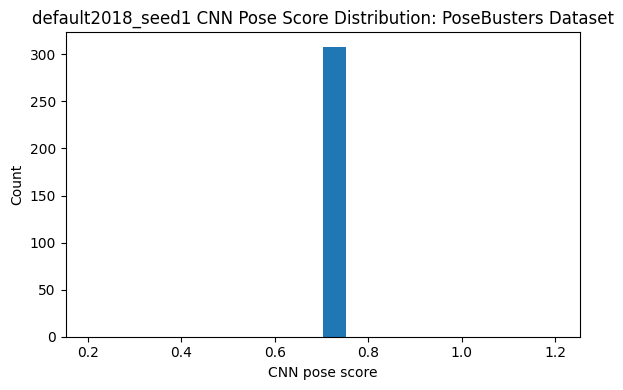

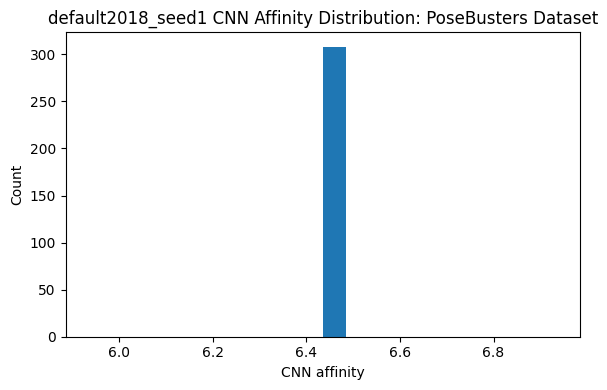

Mean RMSD: 1.53 Å
Median RMSD: 1.49 Å
RMSD < 2 Å: 211/308 (68.51%)
RMSD < 1 Å: 102/308 (33.12%)


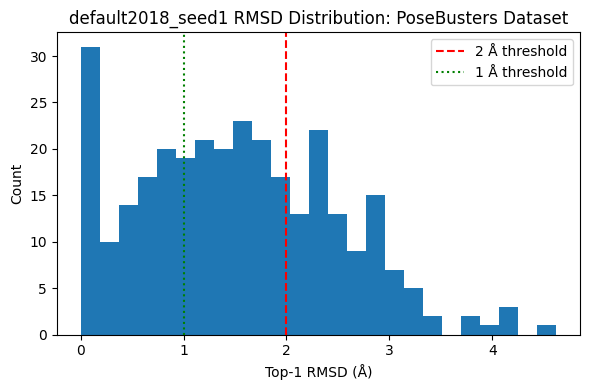

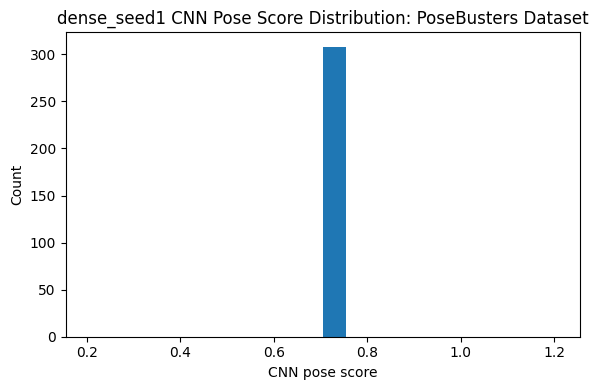

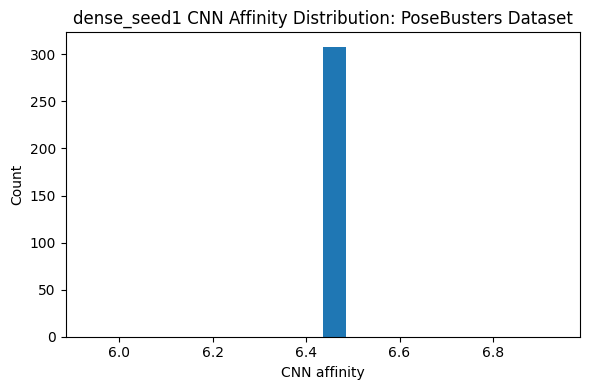

Mean RMSD: 1.53 Å
Median RMSD: 1.49 Å
RMSD < 2 Å: 211/308 (68.51%)
RMSD < 1 Å: 102/308 (33.12%)


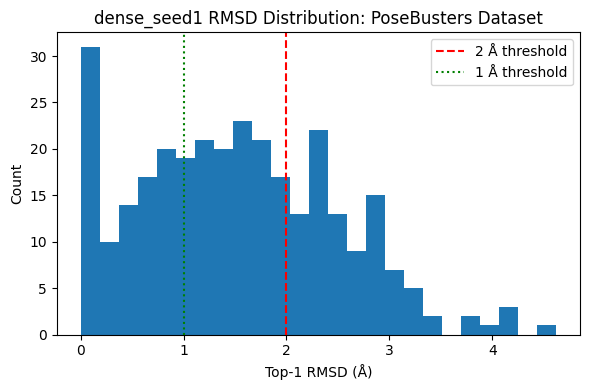

In [83]:
# Plot CNN pose score, CNN affinity, and RMSD distributions for the posebusters dataset

evaluation_csv_names = {
    "default2018_seed1": (
        "posebusters_filtered_evaluation_default2018_seed1_full.csv"
    ),
    "dense_seed1": (
        "posebusters_filtered_evaluation_dense_seed1_full.csv"
    ),
}

for model_name, csv_name in evaluation_csv_names.items():

    evaluation_csv = RESULTS_PT / csv_name
    evaluation = pd.read_csv(evaluation_csv)


    # Distribution of CNN pose scores
    cnn_pose_vals = pd.to_numeric(
        evaluation["CNNpose_score"],
    )
    plt.figure(figsize=(6, 4))
    plt.hist(cnn_pose_vals, bins=20)
    plt.title(f"{model_name} CNN Pose Score Distribution: PoseBusters Dataset")
    plt.xlabel("CNN pose score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


    # Distribution of CNN affinity scores
    cnn_affinity_vals = pd.to_numeric(
        evaluation["CNNaffinity"],
    )
    plt.figure(figsize=(6, 4))
    plt.hist(cnn_affinity_vals, bins=20)
    plt.title(f"{model_name} CNN Affinity Distribution: PoseBusters Dataset")
    plt.xlabel("CNN affinity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
 

    # RMSD score distribution
    
    rmsd_vals = pd.to_numeric(
        evaluation["rmsd"],
    )
    evaluated_count = len(rmsd_vals)
    rmsd_lt2_count = int((rmsd_vals < 2.0).sum())
    rmsd_lt1_count = int((rmsd_vals < 1.0).sum())


    if evaluated_count > 0:
        print(f"Mean RMSD: {rmsd_vals.mean():.2f} Å")
        print(f"Median RMSD: {rmsd_vals.median():.2f} Å")
        print(
            f"RMSD < 2 Å: "
            f"{rmsd_lt2_count}/{evaluated_count} "
            f"({rmsd_lt2_count / evaluated_count:.2%})"
        )
        print(
            f"RMSD < 1 Å: "
            f"{rmsd_lt1_count}/{evaluated_count} "
            f"({rmsd_lt1_count / evaluated_count:.2%})"
        )

        # RMSD histogram
        plt.figure(figsize=(6, 4))
        plt.hist(rmsd_vals, bins=25)
        plt.axvline( # line for less than 2 Å
            2.0,
            color="red",
            linestyle="--",
            label="2 Å threshold",
        )
        plt.axvline( # line for less than 1 Å
            1.0,
            color="green",
            linestyle=":",
            label="1 Å threshold",
        )
        plt.title(f"{model_name} RMSD Distribution: PoseBusters Dataset")
        plt.xlabel("Top-1 RMSD (Å)")
        plt.ylabel("Count")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
#Figures explanations:

# FOR THE POSEBUSTERS DATASET:
#The RMSD histograms for both retrained GNINA models display a majority of docked ligands falling below the 2 Angstrom threshold (68.51%) , indicating that the retrained model surpassed native GNINA's Top-1 RMSD 66.6%.
#The CNN pose score and CNN affinity histograms shows that each metric, for each ligand docked in both models, are exactly the same. This indicates that training collapse occured during training and that the model did not learn CNN metrics from docking properly.  

PoseBusters analysis: default2018_seed1
PoseBusters valid: 268/308 (87.01%)
PoseBusters invalid: 40/308 (12.99%)
PoseBusters analysis: dense_seed1
PoseBusters valid: 268/308 (87.01%)
PoseBusters invalid: 40/308 (12.99%)


,model,valid,invalid,total
0,default2018_seed1,268,40,308
1,dense_seed1,268,40,308


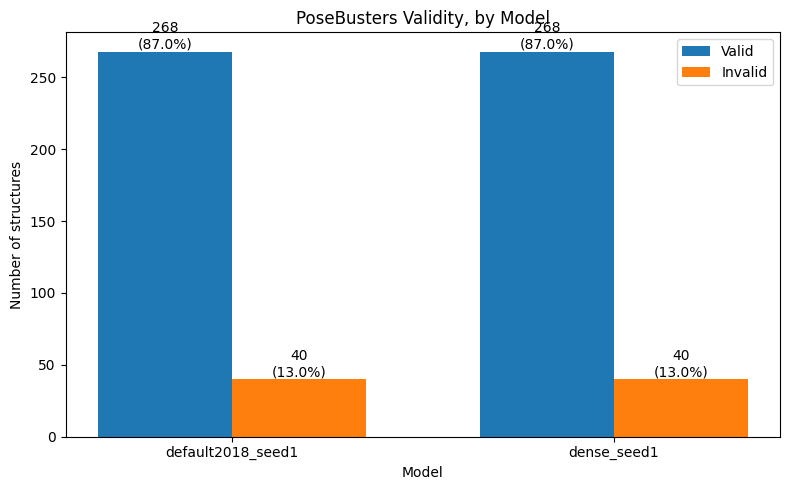

,default2018_seed1,dense_seed1,total_failures
internal_energy,2,2,4
internal_steric_clash,3,3,6
minimum_distance_to_organic_cofactors,3,3,6
volume_overlap_with_protein,11,11,22
minimum_distance_to_protein,35,35,70


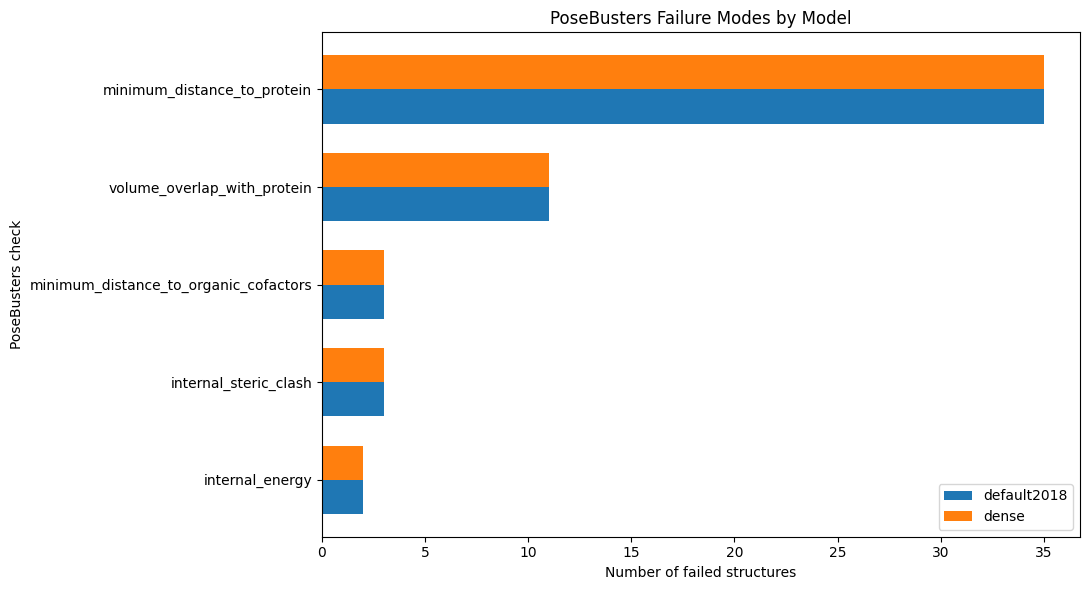

In [ ]:
### POSEBUSTERS RESULTS

# Validity check columns:
POSEBUSTERS_CHECKS = [
    "mol_pred_loaded",
    "mol_cond_loaded",
    "sanitization",
    "inchi_convertible",
    "all_atoms_connected",
    "no_radicals",
    "bond_lengths",
    "bond_angles",
    "internal_steric_clash",
    "aromatic_ring_flatness",
    "non-aromatic_ring_non-flatness",
    "double_bond_flatness",
    "internal_energy",
    "protein-ligand_maximum_distance",
    "minimum_distance_to_protein",
    "minimum_distance_to_organic_cofactors",
    "minimum_distance_to_inorganic_cofactors",
    "minimum_distance_to_waters",
    "volume_overlap_with_protein",
    "volume_overlap_with_organic_cofactors",
    "volume_overlap_with_inorganic_cofactors",
    "volume_overlap_with_waters",
]


# Evaluation files are in results/
evaluation_files = {
    "default2018_seed1": (
        RESULTS_PT
        / "posebusters_filtered_evaluation_default2018_seed1_full.csv"
    ),
    "dense_seed1": (
        RESULTS_PT
        / "posebusters_filtered_evaluation_dense_seed1_full.csv"
    ),
}

"""
Posebusters analysis for both Posebusters evaluations on dense and default2018
"""

combined_pb_results = [] # table for us to visualize
combined_failure_counts = {}

for model_name, evaluation_csv in evaluation_files.items(): # for both models

    print(f"PoseBusters analysis: {model_name}")

    if not evaluation_csv.exists():
        print(f"Evaluation CSV not found: {evaluation_csv}")
        continue

    evaluation = pd.read_csv(evaluation_csv)
    evaluation.columns = evaluation.columns.str.strip() # columns of csv


    # POsebusters valid/invalid results
    pb_counts = (
        evaluation["pb_valid"]
        .value_counts()
        .reindex([True, False], fill_value=0)
    )

    pass_count = int(pb_counts.loc[True]) # amount that passed
    fail_count = int(pb_counts.loc[False]) # amount that didn't pass
    total_count = pass_count + fail_count

    combined_pb_results.append(
        {
            "model": model_name,
            "valid": pass_count,
            "invalid": fail_count,
            "total": total_count,
        }
    )

    if total_count > 0:
        print(
            f"PoseBusters valid: {pass_count}/{total_count} "
            f"({pass_count / total_count:.2%})"
        )
        print(
            f"PoseBusters invalid: {fail_count}/{total_count} "
            f"({fail_count / total_count:.2%})"
        )

    # PoseBusters failure count checks for the model
    model_failure_counts = {}
    for check in POSEBUSTERS_CHECKS:
        valid_values = evaluation[check].dropna()
        model_failure_counts[check] = int(
            (valid_values == False).sum()
        )

    combined_failure_counts[model_name] = model_failure_counts

# For both models, plot valid/invalid models
combined_pb_df = pd.DataFrame(combined_pb_results)
display(combined_pb_df) # display posebusters result to view

# Bar plot
x_positions = np.arange(len(combined_pb_df))
bar_width = 0.35
plt.figure(figsize=(8, 5))
valid_bars = plt.bar(
        x_positions - bar_width / 2,
        combined_pb_df["valid"],
        width=bar_width,
        label="Valid",
    )

invalid_bars = plt.bar(
        x_positions + bar_width / 2,
        combined_pb_df["invalid"],
        width=bar_width,
        label="Invalid",
    )

for bars, count_column in [
        (valid_bars, "valid"),
        (invalid_bars, "invalid"),
    ]:
        for bar, count, total in zip(
            bars,
            combined_pb_df[count_column],
            combined_pb_df["total"],
        ):
            percentage = (
                count / total * 100
                if total > 0
                else 0
            )

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{count}\n({percentage:.1f}%)",
                ha="center",
                va="bottom",
            )

model_labels = (
        combined_pb_df["model"]
    )

plt.xticks(
        x_positions,
        model_labels,
    )

plt.title("PoseBusters Validity, by Model")
plt.xlabel("Model")
plt.ylabel("Number of structures")
plt.legend()
plt.tight_layout()
plt.show()
    

# Posebusters check failure mode bar plot, for btoh models

failure_counts_df = pd.DataFrame(
    combined_failure_counts
).astype(int)

# only keep checks with at least one failure in either model.
failure_counts_df = failure_counts_df[
    failure_counts_df.sum(axis=1) > 0
]

# sort by increasing order by the combined number of failures across both models
failure_counts_df["total_failures"] = (
    failure_counts_df.sum(axis=1)
)
failure_counts_df = failure_counts_df.sort_values(
    "total_failures",
    ascending=True,
)

display(failure_counts_df)


y_positions = np.arange(len(failure_counts_df))
bar_height = 0.35
model_names = list(failure_counts_df.columns)

plt.figure(
    figsize=(
        11,
        max(6, len(failure_counts_df) * 0.45),
    )
)

model_bars1 = plt.barh(
        y_positions - bar_height / 2,
        failure_counts_df[model_names[0]],
        height=bar_height,
        label=(
            model_names[0]
        ),
    )

model_bars2 = plt.barh(
    y_positions + bar_height / 2,
    failure_counts_df[model_names[1]],
    height=bar_height,
    label=(
        model_names[1]
    ),
)

plt.yticks(
    y_positions,
    failure_counts_df.index,
)
plt.title("PoseBusters Failure Modes by Model")
plt.xlabel("Number of failed structures")
plt.ylabel("PoseBusters check")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# POSEBUSTERS VALIDITY RESULTS:
# Looking at the Posebusters validity check metrics, we can observe that the Posebuster validity and the failure point statistics are identical across models, on the same dataset. 
# 87% of the complexes are classified as Posebuster valid: a vast majority. This speaks to the strength of the AutoDock VINA energy minimization function that performs the scoring.
# A majority of the points of failure for the Posebusters invalid complexes/ligands are attributed to "minimum_distance_to_protein" (improper fitting of the ligand into the binding pocket), which could be attributed to the poor RMSD scores of some ligands (>4 Angstroms). The second most frequent point of failure is "volume_overlap_with_protein" (steric hindrance between the ligand and the amino acids in the binding pocket).

In [88]:
# Best and worst PoseBusters predictions per model (top 3)
# These tables show the complexes with the lowest and highest RMSD, together with their CNN pose and affinity scores.

best_k = 3
worst_k = 3

evaluation_files = {
    "default2018_seed1": (
        RESULTS_PT
        / "posebusters_filtered_evaluation_default2018_seed1_full.csv"
    ),
    "dense_seed1": (
        RESULTS_PT
        / "posebusters_filtered_evaluation_dense_seed1_full.csv"
    ),
}


for model_name, evaluation_csv in evaluation_files.items():

    print(f"\n{'-' * 100}")
    print(f"Best and worst predictions for the Posebusters dataset: {model_name}")
    print(f"{'-' * 100}")

    evaluation = pd.read_csv(evaluation_csv)
    evaluation.columns = evaluation.columns.str.strip()
    complex_id_column = "complex_id"

    # Convert RMSD and CNN metrics to numeric
    for column in [
        "rmsd",
        "CNNpose_score",
        "CNNaffinity",
    ]:
        if column in evaluation.columns:
            evaluation[column] = pd.to_numeric(
                evaluation[column],
                errors="coerce",
            )


    display_columns = [ # in table
        complex_id_column,
        "rmsd",
        "CNNpose_score",
        "CNNaffinity",
    ]


    best_predictions = (
        evaluation
        .sort_values(
            by="rmsd",
            ascending=True,
        )
        .head(best_k) # top 3
        [display_columns]
        .reset_index(drop=True)
    )

    worst_predictions = (
        evaluation
        .sort_values(
            by="rmsd",
            ascending=False,
        )
        .head(worst_k) # bottom 3
        [display_columns]
        .reset_index(drop=True)
    )

    print(
        f"\n{model_name}: "
        f"Best {len(best_predictions)} Posebusters predictions with lowest RMSD"
    )
    display(best_predictions)

    print(
        f"\n{model_name}: "
        f"Worst {len(worst_predictions)} Posebusters predictions with highest RMSD"
    )
    display(worst_predictions)


----------------------------------------------------------------------------------------------------
Best and worst predictions for the Posebusters dataset: default2018_seed1
----------------------------------------------------------------------------------------------------

default2018_seed1: Best 3 Posebusters predictions with lowest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,7BJJ_TVW,0.0,0.70283,6.434926
1,7C3U_AZG,0.0,0.70283,6.434926
2,7WKL_CAQ,0.0,0.70283,6.434926



default2018_seed1: Worst 3 Posebusters predictions with highest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,7EPV_FDA,4.6216,0.70283,6.434926
1,7ROU_66I,4.2106,0.70283,6.434926
2,7C0U_FGO,4.0877,0.70283,6.434926



----------------------------------------------------------------------------------------------------
Best and worst predictions for the Posebusters dataset: dense_seed1
----------------------------------------------------------------------------------------------------

dense_seed1: Best 3 Posebusters predictions with lowest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,7BJJ_TVW,0.0,0.70516,6.435945
1,7C3U_AZG,0.0,0.70516,6.435945
2,7WKL_CAQ,0.0,0.70516,6.435945



dense_seed1: Worst 3 Posebusters predictions with highest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,7EPV_FDA,4.6216,0.70516,6.435945
1,7ROU_66I,4.2106,0.70516,6.435945
2,7C0U_FGO,4.0877,0.70516,6.435945


In [ ]:
# FOR POSEBUSTERS:

# The complexes with the best RMSD scores display a flawless RMSD of 0.0 Angstroms, while the worst RMSD scores are within a range of 4.0877-4.6216 Angstroms, improving on the worst RMSD value observed in the prototype model, of 14.5 Angstroms. 
# So, the full dataset training of the model resulted in signficantly improved RMSD values.
# However, unlike the successful generation of a CNNpose_score and CNNaffinity distribution in the prototype model, there exists a constant level set for the CNN metrics in the full model, indicating that the full model training collapsed for the CNN metrics. 

In [87]:
# summary Posebusters docking metrics for every retrained GNINA model

all_sums = []

evaluation_files = {
    "default2018_seed1": (
        RESULTS_PT
        / "posebusters_filtered_evaluation_default2018_seed1_full.csv"
    ),
    "dense_seed1": (
        RESULTS_PT
        / "posebusters_filtered_evaluation_dense_seed1_full.csv"
    ),
}


for model_name, evaluation_csv in evaluation_files.items():
    evaluation = pd.read_csv(evaluation_csv)

    # Convert RMSD to numeric
    evaluation["rmsd"] = pd.to_numeric(
        evaluation["rmsd"],
    )

    valid_rmsd = evaluation["rmsd"].dropna()
    total_rows = len(evaluation) # all complexes
    n_valid = len(valid_rmsd) # all valid complexes that are not na
    missing_rmsd = total_rows - n_valid 


    # RMSD success thresholds for top1
    under2_count = int((valid_rmsd < 2.0).sum())
    under1_count = int((valid_rmsd < 1.0).sum())
    failures = int((valid_rmsd >= 2.0).sum()) # anything over 2
    med_rmsd = float(valid_rmsd.median()) # medians
    mean_rmsd = float(valid_rmsd.mean())

    summary_row = { # dict of summary stats
        "Model (Docked Posebusters)": (
            model_name
            .replace("_seed1", "")
            .replace("default2018", "Default2018")
            .replace("dense", "Dense")
        ),
        "Total evaluation rows": len(evaluation),
        "Valid RMSD values": n_valid,
        "Missing RMSD values": missing_rmsd,
        "RMSD < 2.0 Å (Top-1)": (
            f"{under2_count / n_valid * 100:.1f}% "
            f"({under2_count}/{n_valid})"
        ),
        "RMSD < 1.0 Å (Top-1)": (
            f"{under1_count / n_valid * 100:.1f}% "
            f"({under1_count}/{n_valid})"
        ),
        "Median RMSD": f"{med_rmsd:.2f} Å",
        "Mean RMSD": f"{mean_rmsd:.2f} Å",
        "Failures (RMSD ≥ 2.0 Å)": failures,
    }

    # Add PoseBusters validity metrics 
    if "pb_valid" in evaluation.columns:
     
        pb_values = evaluation["pb_valid"].dropna()

        pb_valid_count = int((pb_values == True).sum())
        pb_invalid_count = int((pb_values == False).sum())
        pb_total = pb_valid_count + pb_invalid_count

        summary_row["PoseBusters valid"] = (
            f"{pb_valid_count / pb_total * 100:.1f}% " #percentage
            f"({pb_valid_count}/{pb_total})"
            if pb_total > 0
            else "N/A"
        )

        summary_row["PoseBusters invalid"] = (
            f"{pb_invalid_count / pb_total * 100:.1f}% " #percentage
            f"({pb_invalid_count}/{pb_total})"
            if pb_total > 0
            else "N/A"
        )

    all_sums.append(summary_row)


# Create and display the summary table.
df_all_sums = pd.DataFrame(all_sums)

display(df_all_sums)



   

,Model (Docked Posebusters),Total evaluation rows,Valid RMSD values,Missing RMSD values,RMSD < 2.0 Å (Top-1),RMSD < 1.0 Å (Top-1),Median RMSD,Mean RMSD,Failures (RMSD ≥ 2.0 Å),PoseBusters valid,PoseBusters invalid
0,Default2018,308,306,2,69.0% (211/306),33.3% (102/306),1.49 Å,1.53 Å,95,87.0% (268/308),13.0% (40/308)
1,Dense,308,306,2,69.0% (211/306),33.3% (102/306),1.49 Å,1.53 Å,95,87.0% (268/308),13.0% (40/308)


In [98]:
"""
Secondly, with the docked test dataset, onto the preexisting evaluation.py-generated CSV files, add on CNNaffinity and CNNpose score as new columns in the CSV. Use CNN_metrics_to_csv.py to first parse the CNNaffinity and CNNpose_score values from the .sdf files to add to the csvs.  
"""

# Map each model to its evaluation CSV filename with a dict
evaluation_csv_files = {
    "default2018_seed1": (
        RESULTS_PT
        / "full_sealed_test_evaluation_default2018_seed1_RMSDonly.csv"
    ),
    "dense_seed1": (
        RESULTS_PT
        / "full_sealed_test_evaluation_dense_seed1_RMSDonly.csv"
    ),
}

def find_model_sdf_directory(model_name: str) -> Path:
    """
    Find the directory under TEST_PT that contains the prediction SDF
    files for the requested model.
    """
    # Test dir: results/full_test_redocked/default2018_seed1/*.sdf
    model_path = TEST_PT / model_name

    if model_path.is_dir() and any(model_path.glob("*.sdf")): # make sure .sdfs are inside
        return model_path
    
"""
Now, actually update the csv with the new CNN metrics
""" 

updated_evaluation_dfs = {}

for model_name, csv_name in evaluation_csv_names.items():
    evaluation_csv = find_evaluation_csv(csv_name) # get the preexisting eval csv
    model_sdf_dir = find_model_sdf_directory(model_name) # get the dir of sdfs

    updated_evaluation_dfs[model_name] = (
        add_cnn_metrics_to_evaluation_csv(
            model_name=model_name,
            evaluation_csv=evaluation_csv,
            model_sdf_dir=model_sdf_dir,
            overwrite=True,
        )
    )

Saved updated CSV to: results\full_sealed_test_evaluation_default2018_seed1_RMSDonly.csv
Saved updated CSV to: results\full_sealed_test_evaluation_dense_seed1_RMSDonly.csv


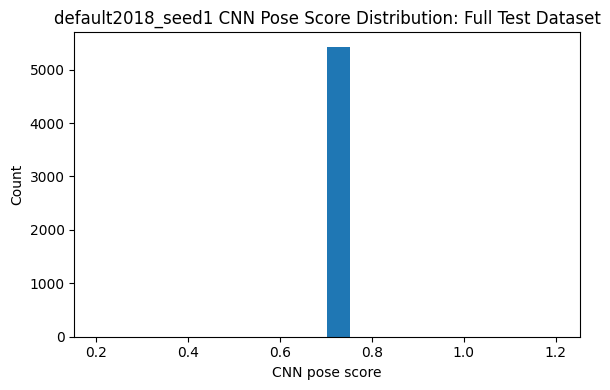

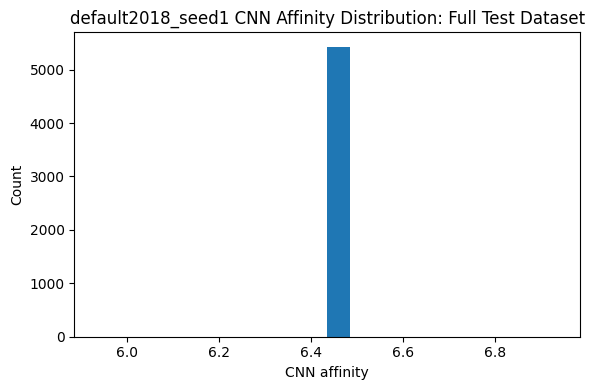

Mean RMSD: 1.78 Å
Median RMSD: 1.67 Å
RMSD < 2 Å: 3416/5426 (62.96%)
RMSD < 1 Å: 1309/5426 (24.12%)


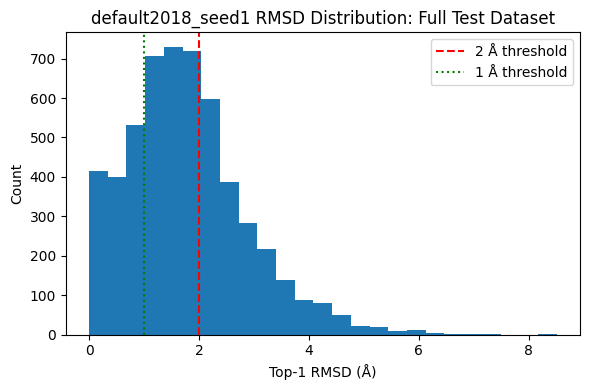

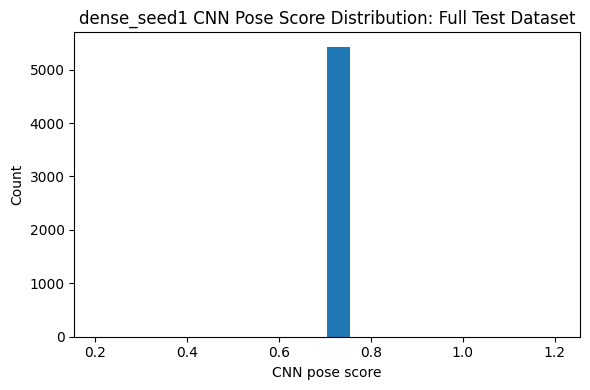

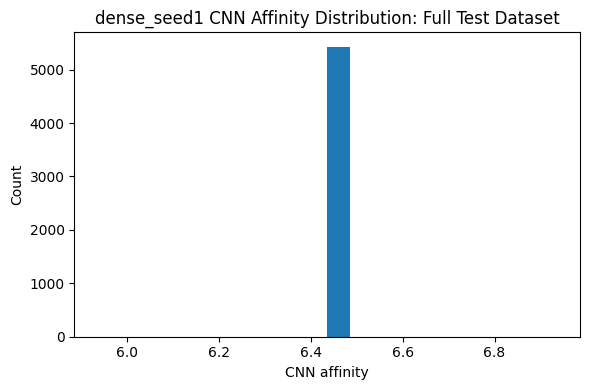

Mean RMSD: 1.78 Å
Median RMSD: 1.67 Å
RMSD < 2 Å: 3416/5426 (62.96%)
RMSD < 1 Å: 1309/5426 (24.12%)


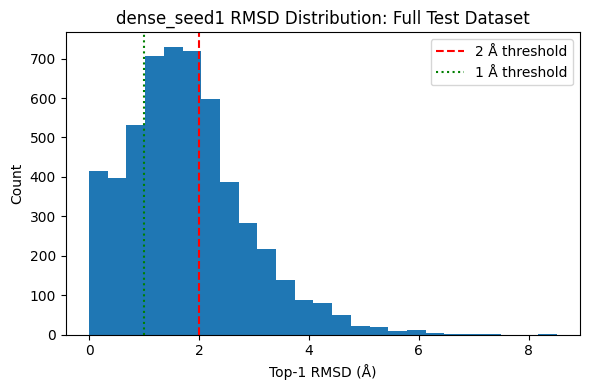

In [99]:
# Plot CNN pose score, CNN affinity, and RMSD distributions for the docked test set

evaluation_csv_names = {
    "default2018_seed1": (
        "full_sealed_test_evaluation_default2018_seed1_RMSDonly.csv"
    ),
    "dense_seed1": (
        "full_sealed_test_evaluation_dense_seed1_RMSDonly.csv"
    ),
}

for model_name, csv_name in evaluation_csv_names.items():

    evaluation_csv = RESULTS_PT / csv_name
    evaluation = pd.read_csv(evaluation_csv)


    # Distribution of CNN pose scores
    cnn_pose_vals = pd.to_numeric(
        evaluation["CNNpose_score"],
    )
    plt.figure(figsize=(6, 4))
    plt.hist(cnn_pose_vals, bins=20)
    plt.title(f"{model_name} CNN Pose Score Distribution: Full Test Dataset")
    plt.xlabel("CNN pose score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


    # Distribution of CNN affinity scores
    cnn_affinity_vals = pd.to_numeric(
        evaluation["CNNaffinity"],
    )
    plt.figure(figsize=(6, 4))
    plt.hist(cnn_affinity_vals, bins=20)
    plt.title(f"{model_name} CNN Affinity Distribution: Full Test Dataset")
    plt.xlabel("CNN affinity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
 

    # RMSD score distribution
    
    rmsd_vals = pd.to_numeric(
        evaluation["rmsd"],
    )
    evaluated_count = len(rmsd_vals)
    rmsd_lt2_count = int((rmsd_vals < 2.0).sum())
    rmsd_lt1_count = int((rmsd_vals < 1.0).sum())


    if evaluated_count > 0:
        print(f"Mean RMSD: {rmsd_vals.mean():.2f} Å")
        print(f"Median RMSD: {rmsd_vals.median():.2f} Å")
        print(
            f"RMSD < 2 Å: "
            f"{rmsd_lt2_count}/{evaluated_count} "
            f"({rmsd_lt2_count / evaluated_count:.2%})"
        )
        print(
            f"RMSD < 1 Å: "
            f"{rmsd_lt1_count}/{evaluated_count} "
            f"({rmsd_lt1_count / evaluated_count:.2%})"
        )

        # RMSD histogram
        plt.figure(figsize=(6, 4))
        plt.hist(rmsd_vals, bins=25)
        plt.axvline( # line for less than 2 Å
            2.0,
            color="red",
            linestyle="--",
            label="2 Å threshold",
        )
        plt.axvline( # line for less than 1 Å
            1.0,
            color="green",
            linestyle=":",
            label="1 Å threshold",
        )
        plt.title(f"{model_name} RMSD Distribution: Full Test Dataset")
        plt.xlabel("Top-1 RMSD (Å)")
        plt.ylabel("Count")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
#Figures explanations:

# FOR THE TEST DATASET:
#As with the Posebusters set, the RMSD histograms for both retrained GNINA models display a majority (62.96%) of docked ligands falling below the 2 Angstrom threshold, slightly falling below native GNINA's Top-1 RMSD 66.6%.
#Also observed with the Posebusters dataset, the CNN pose score and CNN affinity histograms shows that each metric, for each ligand docked in both models, are exactly the same. This indicates that training collapse occured during training and that the model did not learn CNN metrics from docking properly.  

In [100]:
# Best and worst full test set predictions per model (top 3)
# These tables show the complexes with the lowest and highest RMSD, together with their CNN pose and affinity scores.

best_k = 3
worst_k = 3

evaluation_files = {
    "default2018_seed1": (
        RESULTS_PT
        / "full_sealed_test_evaluation_default2018_seed1_RMSDonly.csv"
    ),
    "dense_seed1": (
        RESULTS_PT
        / "full_sealed_test_evaluation_dense_seed1_RMSDonly.csv"
    ),
}


for model_name, evaluation_csv in evaluation_files.items():

    print(f"\n{'-' * 100}")
    print(f"Best and worst predictions the full test dataset: {model_name}")
    print(f"{'-' * 100}")

    evaluation = pd.read_csv(evaluation_csv)
    evaluation.columns = evaluation.columns.str.strip()
    complex_id_column = "complex_id"

    # Convert RMSD and CNN metrics to numeric
    for column in [
        "rmsd",
        "CNNpose_score",
        "CNNaffinity",
    ]:
        if column in evaluation.columns:
            evaluation[column] = pd.to_numeric(
                evaluation[column],
                errors="coerce",
            )


    display_columns = [ # in table
        complex_id_column,
        "rmsd",
        "CNNpose_score",
        "CNNaffinity",
    ]


    best_predictions = (
        evaluation
        .sort_values(
            by="rmsd",
            ascending=True,
        )
        .head(best_k) # top 3
        [display_columns]
        .reset_index(drop=True)
    )

    worst_predictions = (
        evaluation
        .sort_values(
            by="rmsd",
            ascending=False,
        )
        .head(worst_k) # bottom 3
        [display_columns]
        .reset_index(drop=True)
    )

    print(
        f"\n{model_name}: "
        f"Best {len(best_predictions)} full test set predictions with lowest RMSD"
    )
    display(best_predictions)

    print(
        f"\n{model_name}: "
        f"Worst {len(worst_predictions)} full test set predictions with highest RMSD"
    )
    display(worst_predictions)


----------------------------------------------------------------------------------------------------
Best and worst predictions the full test dataset: default2018_seed1
----------------------------------------------------------------------------------------------------

default2018_seed1: Best 3 full test set predictions with lowest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,1bky_1MC_A_600,0.0,0.70283,6.434926
1,1b42_M1A_A_600,0.0,0.70283,6.434926
2,1a9t_HPA_A_290,0.0,0.70283,6.434926



default2018_seed1: Worst 3 full test set predictions with highest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,5jsm_6NB_C_801,8.5060,0.70283,6.434926
1,2bqz_ARG-TYR_F_17-26,7.3968,0.70283,6.434926
2,2puy_ALA-SER_E_1-10,6.8737,0.70283,6.434926



----------------------------------------------------------------------------------------------------
Best and worst predictions the full test dataset: dense_seed1
----------------------------------------------------------------------------------------------------

dense_seed1: Best 3 full test set predictions with lowest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,1bky_1MC_A_600,0.0,0.70516,6.435945
1,1b42_M1A_A_600,0.0,0.70516,6.435945
2,1a9t_HPA_A_290,0.0,0.70516,6.435945



dense_seed1: Worst 3 full test set predictions with highest RMSD


,complex_id,rmsd,CNNpose_score,CNNaffinity
0,5jsm_6NB_C_801,8.5060,0.70516,6.435945
1,2bqz_ARG-TYR_F_17-26,7.3968,0.70516,6.435945
2,2puy_ALA-SER_E_1-10,6.8737,0.70516,6.435945


In [ ]:
# FOR THE TEST SET:

# Once again, the best RMSD scores display a flawless RMSD of 0.0 Angstroms. However, the worst RMSD scores are within a range of 6.8737-8.5060 Angstroms, improving on the worst RMSD value observed in the prototype model, of 14.5 Angstroms. Notably, the median RMSD values for the prototype dataset was 8.54 and 8.98 Angstroms, and the mean prototype RMSD values were 8.01 and 8.24 Angstroms, for the dense and default2018 models, respectively. 
# Thus, the full retrained models significantly improved the RMSD values. 
# However, unlike the successful generation of a CNNpose_score and CNNaffinity distribution in the prototype model, there exists a constant level set for the CNN metrics in the full model, indicating that the full model training collapsed for the CNN metrics. 

In [103]:
# summary full test set docking metrics for every retrained GNINA model

all_sums = []

evaluation_csv_files = {
    "default2018_seed1": (
        RESULTS_PT
        / "full_sealed_test_evaluation_default2018_seed1_RMSDonly.csv"
    ),
    "dense_seed1": (
        RESULTS_PT
        / "full_sealed_test_evaluation_dense_seed1_RMSDonly.csv"
    ),
}


for model_name, evaluation_csv in evaluation_csv_files.items():
    evaluation = pd.read_csv(evaluation_csv)

    # Convert RMSD to numeric
    evaluation["rmsd"] = pd.to_numeric(
        evaluation["rmsd"],
    )

    valid_rmsd = evaluation["rmsd"].dropna()
    total_rows = len(evaluation) # all complexes
    n_valid = len(valid_rmsd) # all valid complexes that are not na
    missing_rmsd = total_rows - n_valid 


    # RMSD success thresholds for top1
    under2_count = int((valid_rmsd < 2.0).sum())
    under1_count = int((valid_rmsd < 1.0).sum())
    failures = int((valid_rmsd >= 2.0).sum()) # anything over 2
    med_rmsd = float(valid_rmsd.median()) # medians
    mean_rmsd = float(valid_rmsd.mean())

    summary_row = { # dict of summary stats
        "Model (Docked Test Set)": (
            model_name
            .replace("_seed1", "")
            .replace("default2018", "Default2018")
            .replace("dense", "Dense")
        ),
        "Total evaluation rows": len(evaluation),
        "Valid RMSD values": n_valid,
        "Missing RMSD values": missing_rmsd,
        "RMSD < 2.0 Å (Top-1)": (
            f"{under2_count / n_valid * 100:.1f}% "
            f"({under2_count}/{n_valid})"
        ),
        "RMSD < 1.0 Å (Top-1)": (
            f"{under1_count / n_valid * 100:.1f}% "
            f"({under1_count}/{n_valid})"
        ),
        "Median RMSD": f"{med_rmsd:.2f} Å",
        "Mean RMSD": f"{mean_rmsd:.2f} Å",
        "Failures (RMSD ≥ 2.0 Å)": failures,
    }

    all_sums.append(summary_row)


# Create and display the summary table.
df_all_sums = pd.DataFrame(all_sums)

display(df_all_sums)

   

,Model (Docked Test Set),Total evaluation rows,Valid RMSD values,Missing RMSD values,RMSD < 2.0 Å (Top-1),RMSD < 1.0 Å (Top-1),Median RMSD,Mean RMSD,Failures (RMSD ≥ 2.0 Å)
0,Default2018,5426,5418,8,63.0% (3416/5418),24.2% (1309/5418),1.67 Å,1.78 Å,2002
1,Dense,5426,5418,8,63.0% (3416/5418),24.2% (1309/5418),1.67 Å,1.78 Å,2002


In [ ]:
# Discussion:

# Training progressed for 5 epochs with the default hyperparameters listed in the literature by McNutt et. al. Training did not demonstrate a significant reduction in loss over the epochs, indicating that a greater amount of epochs are needed to better train the model. For the default2018 model, the loss barely changed across all five epochs. 

# Overall, the training of these GNINA default2018 and dense models with the full training dataset and validation set drastically improved the RMSD scores of the docked poses.
# However, training on the CNN metrics associated with GNINA (CNNpose_score and CNNaffinity) seemed to collapse, as indicated by the constant outputs of these metrics across all protein/ligand complexes across all 10 poses per complex. 

# ON THE TEST SET:
# The percentages of RMSD failures (> 2 Angstroms) drastically decreased with the full training set, with the default2018 model experiencing failure percentages dropping from ~98% (133/136) to ~37% (2002/5418) and ~99% (134/136) to ~37% (2002/5418).
# For the default2018 and dense models, respectively, the RMSD < 1.0 Å (Top-1) score percentages increased from 0.7% and 1.5% in the prototype models to 24.2% in both full trained models. 
# As discussed previously, the fully trained models exhibit significantly reduced RMSD Å for both the Posebusters and the full test set, docked to the retrained full models. 

# ON THE POSEBUSTERS DATASET, a vast majority of the complexes were deemed Posebusters valid (87%).

# However, for the CNN metrics specific to GNINA (CNNpose_score and CNNaffinity), for each model and across ALL complexes, the CNN metrics were constant. This was not the case in the prototype model. 
# This discrepancy in training can be observed in the training curves--there seems to be a collapse in training that resulted in this anomaly. Typically, given the superior RMSD scores in the fully trained model, one would expect the CNNPose_score to be higher for better RMSD scores. 
# Perhaps the training's default GNINA parameters were not optimized for this dataset. Or, perhaps our checkpoints were not properly output. 
# It is important to note that GNINA does not natively stop at a fixed number of epochs. There is an iterative learning-rate decrease mechanism that stops the training once the loss does not improve after an x amount of epochs. 
# It is uncertain as to why the CNN metric aspect of the training failed. 

: 